# Task 3: Anomaly Detection in Sensor Data using Wavelet Transform
steps: DWT -> threshold the detail coefficients -> inverse DWT (denoised) -> residual = data - denoised -> big residual = anomaly

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

## Part 1: same as expected output (random sensor data)

coeff lengths: [69, 69, 131, 255, 503]
threshold: 3.7635343098158973
anomalies: 48


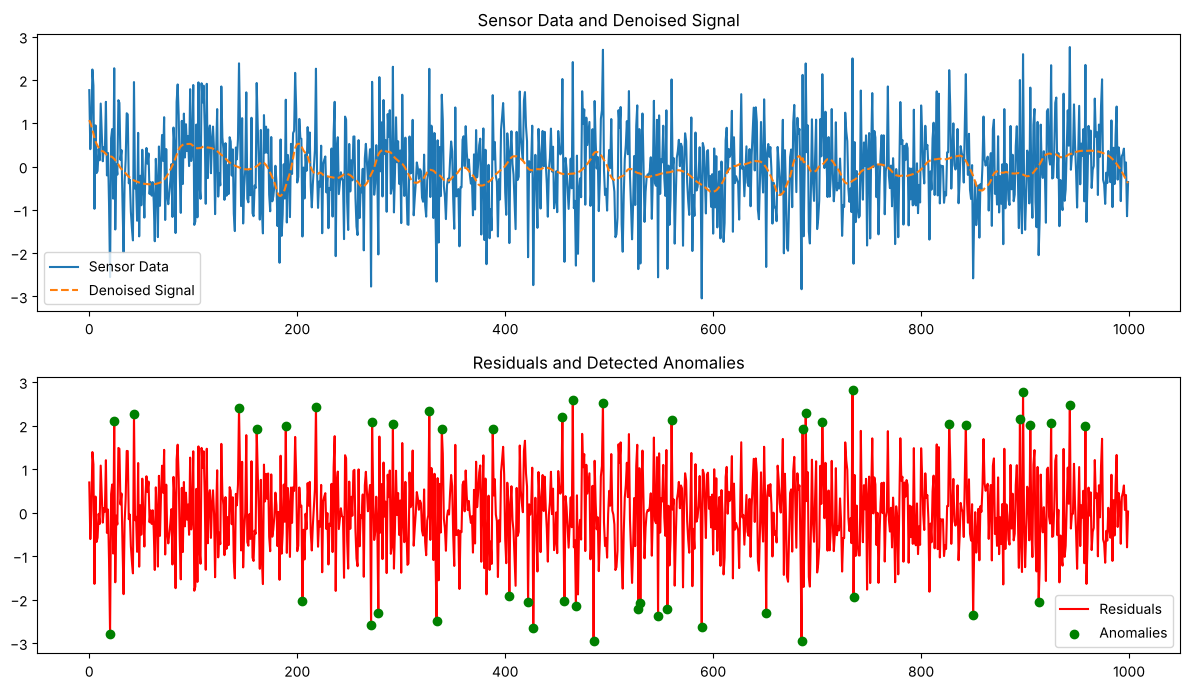

In [2]:
np.random.seed(0)
data = np.random.normal(0, 1, 1000)

coeffs = pywt.wavedec(data, "db4", level=4)
print("coeff lengths:", [len(c) for c in coeffs])

# universal threshold
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
thr = sigma * np.sqrt(2 * np.log(len(data)))
print("threshold:", thr)

new_coeffs = [coeffs[0]]
for c in coeffs[1:]:
    new_coeffs.append(pywt.threshold(c, thr, mode="soft"))
denoised = pywt.waverec(new_coeffs, "db4")[:len(data)]

residuals = data - denoised
limit = 2 * np.std(residuals)
anomalies = np.where(np.abs(residuals) > limit)[0]
print("anomalies:", len(anomalies))

plt.figure(figsize=(12, 7))
plt.subplot(2, 1, 1)
plt.plot(data, label="Sensor Data")
plt.plot(denoised, "--", label="Denoised Signal")
plt.title("Sensor Data and Denoised Signal")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(residuals, "r", label="Residuals")
plt.scatter(anomalies, residuals[anomalies], c="g", label="Anomalies", zorder=3)
plt.title("Residuals and Detected Anomalies")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/task3_expected_output.png")
plt.show()

## Part 2: more real machine signal
random noise doesnt really have anomalies so I made a vibration signal (sine waves + noise) and added some faults myself: 5 spikes, a vibration burst (900-930) and a level shift (1650-1700)

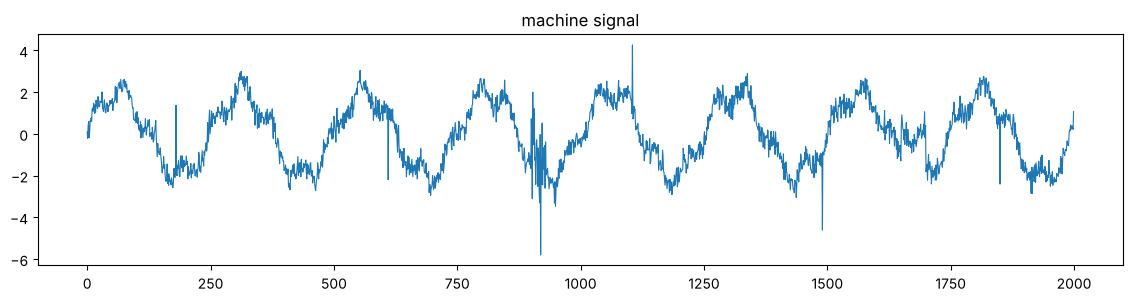

In [3]:
rng = np.random.default_rng(42)
N = 2000
t = np.arange(N)
signal = 2 * np.sin(2 * np.pi * t / 250) + 0.5 * np.sin(2 * np.pi * t / 60) + rng.normal(0, 0.3, N)

spikes = [180, 610, 1105, 1490, 1850]
for s in spikes:
    signal[s] += rng.choice([-1, 1]) * rng.uniform(2.5, 3.5)
signal[900:930] += rng.normal(0, 1.5, 30)
signal[1650:1700] += 1.8

plt.figure(figsize=(14, 3)); plt.plot(signal, lw=0.8); plt.title("machine signal"); plt.show()

limit: 1.1927825118808868  alarms: 17


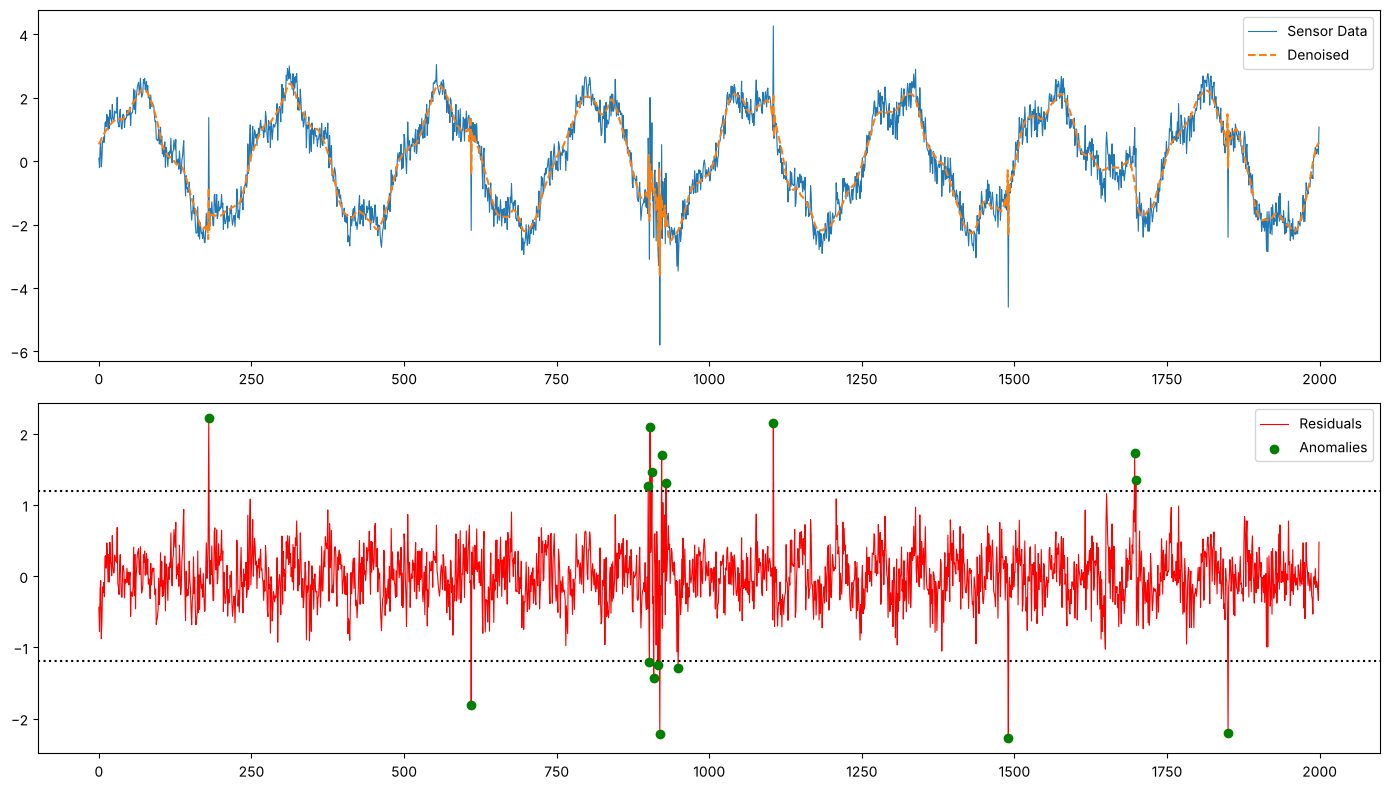

In [4]:
coeffs = pywt.wavedec(signal, "db4", level=5)
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
thr = sigma * np.sqrt(2 * np.log(N))
new_coeffs = [coeffs[0]] + [pywt.threshold(c, thr, "soft") for c in coeffs[1:]]
den = pywt.waverec(new_coeffs, "db4")[:N]
res = signal - den

# using MAD instead of std so the anomalies dont make the limit bigger
mad = np.median(np.abs(res - np.median(res))) / 0.6745
limit = 3.5 * mad
found = np.where(np.abs(res) > limit)[0]
print("limit:", limit, " alarms:", len(found))

plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(signal, lw=0.8, label="Sensor Data")
plt.plot(den, "--", label="Denoised")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(res, "r", lw=0.8, label="Residuals")
plt.axhline(limit, ls=":", c="k"); plt.axhline(-limit, ls=":", c="k")
plt.scatter(found, res[found], c="g", zorder=3, label="Anomalies")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/task3_machine_anomalies.png")
plt.show()

### checking if every fault was caught

In [5]:
faults = [(s, s) for s in spikes] + [(900, 930), (1650, 1700)]
for a, b in faults:
    caught = any(a - 3 <= f <= b + 3 for f in found)
    print("fault", a, "-", b, ":", "caught" if caught else "missed")

wrong = [f for f in found if not any(a - 3 <= f <= b + 3 for a, b in faults)]
print("false alarms:", len(wrong))

fault 180 - 180 : caught
fault 610 - 610 : caught
fault 1105 - 1105 : caught
fault 1490 - 1490 : caught
fault 1850 - 1850 : caught
fault 900 - 930 : caught
fault 1650 - 1700 : caught
false alarms: 1


### coefficients at each level

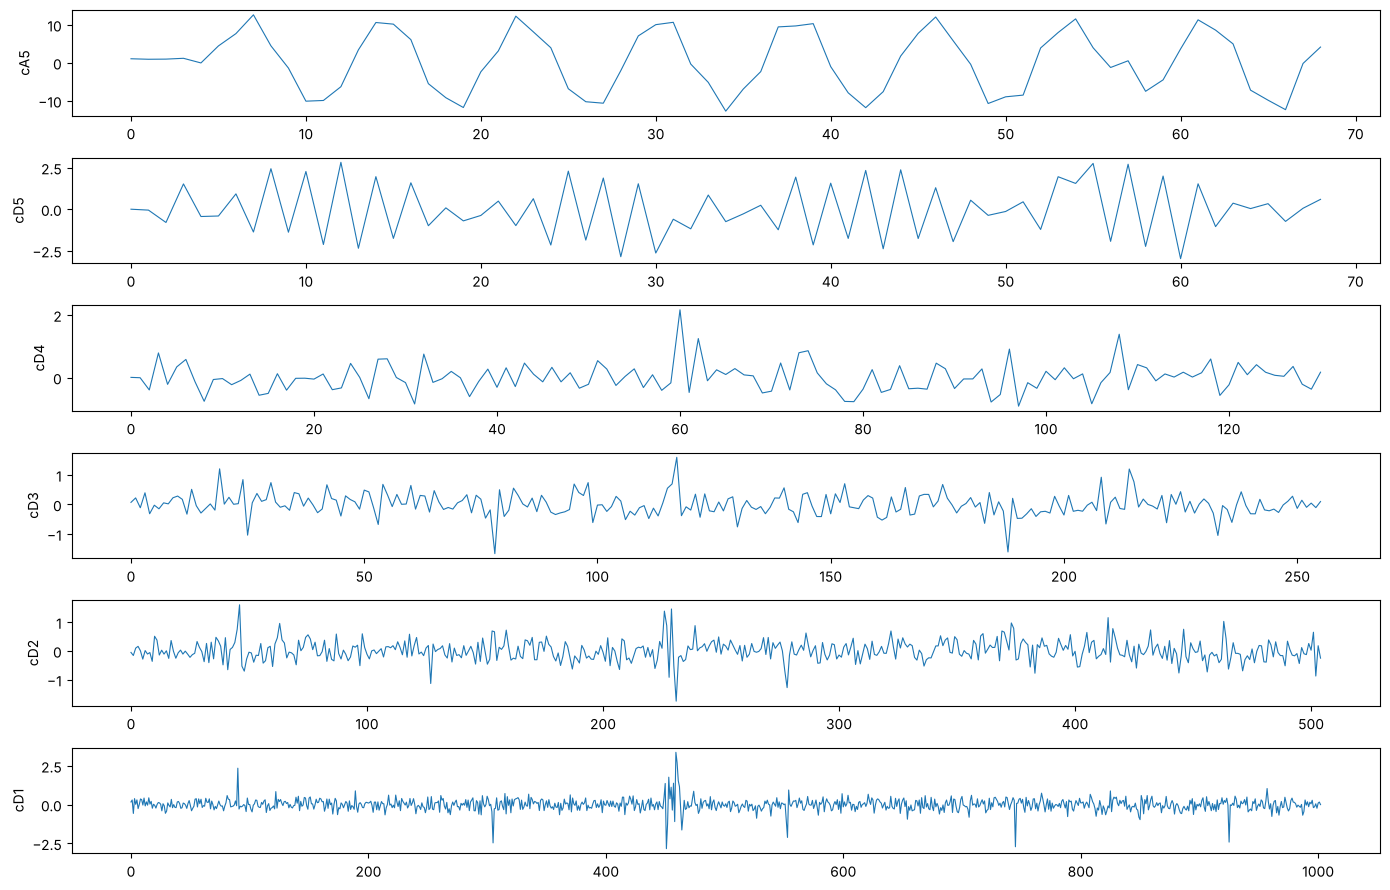

In [6]:
plt.figure(figsize=(14, 9))
for i, c in enumerate(coeffs):
    plt.subplot(len(coeffs), 1, i + 1)
    plt.plot(c, lw=0.8)
    plt.ylabel("cA5" if i == 0 else "cD" + str(len(coeffs) - i))
plt.tight_layout()
plt.show()